# Financial Planning with APIs and Simulations

In this Challenge, you’ll create two financial analysis tools by using a single Jupyter notebook:

Part 1: A financial planner for emergencies. The members will be able to use this tool to visualize their current savings. The members can then determine if they have enough reserves for an emergency fund.

Part 2: A financial planner for retirement. This tool will forecast the performance of their retirement portfolio in 30 years. To do this, the tool will make an Alpaca API call via the Alpaca SDK to get historical price data for use in Monte Carlo simulations.

You’ll use the information from the Monte Carlo simulation to answer questions about the portfolio in your Jupyter notebook.


In [1]:
# Import the required libraries and dependencies
import os
import requests
import json
import pandas as pd
from dotenv import load_dotenv
#import alpaca_trade_api as tradeapi
#from MCForecastTools import MCSimulation


In [2]:
from MCForecastTools26 import MCSimulation

In [5]:
# Load the environment variables from the .env file
#by calling the load_dotenv function
load_dotenv()

True

## Part 1: Create a Financial Planner for Emergencies

### Evaluate the Cryptocurrency Wallet by Using the Requests Library

In this section, you’ll determine the current value of a member’s cryptocurrency wallet. You’ll collect the current prices for the Bitcoin and Ethereum cryptocurrencies by using the Python Requests library. For the prototype, you’ll assume that the member holds the 1.2 Bitcoins (BTC) and 5.3 Ethereum coins (ETH). To do all this, complete the following steps:

1. Create a variable named `monthly_income`, and set its value to `12000`.

2. Use the Requests library to get the current price (in US dollars) of Bitcoin (BTC) and Ethereum (ETH) by using the API endpoints that the starter code supplies.

3. Navigate the JSON response object to access the current price of each coin, and store each in a variable.

    > **Hint** Note the specific identifier for each cryptocurrency in the API JSON response. The Bitcoin identifier is `1`, and the Ethereum identifier is `1027`.

4. Calculate the value, in US dollars, of the current amount of each cryptocurrency and of the entire cryptocurrency wallet.



In [4]:
# The current number of coins for each cryptocurrency asset held in the portfolio.
btc_coins = 1.2
eth_coins = 5.3

#### Step 1: Create a variable named `monthly_income`, and set its value to `12000`.

In [5]:
# The monthly amount for the member's household income
monthly_income = 12000

#### Review the endpoint URLs for the API calls to Free Crypto API in order to get the current pricing information for both BTC and ETH.

In [6]:
# The Free Crypto API Call endpoint URLs for the held cryptocurrency assets
btc_url = "https://api.alternative.me/v2/ticker/Bitcoin/?convert=USD"
eth_url = "https://api.alternative.me/v2/ticker/Ethereum/?convert=USD"

#### Step 2. Use the Requests library to get the current price (in US dollars) of Bitcoin (BTC) and Ethereum (ETH) by using the API endpoints that the starter code supplied.

In [7]:
# Using the Python requests library, make an API call to access the current price of BTC
btc_response = requests.get(btc_url)

# Use the json.dumps function to review the response data from the API call
# Use the indent and sort_keys parameters to make the response object readable
btc_response.status_code

200

In [8]:
btc_response.ok

True

In [9]:
btc_response.text

'{\n\t"data": {\n\t\t"1": {\n\t\t\t"id": 1,\n\t\t\t"name": "Bitcoin",\n\t\t\t"symbol": "BTC",\n\t\t\t"website_slug": "bitcoin",\n\t\t\t"rank": 1,\n\t\t\t"circulating_supply": 20003043,\n\t\t\t"total_supply": 20003043,\n\t\t\t"max_supply": 20003043,\n\t\t\t"quotes": {\n\t\t\t\t"USD": {\n\t\t\t\t\t"price": 70997.0000000000000000,\n\t\t\t\t\t"volume_24h": 56282723187,\n\t\t\t\t\t"market_cap": 1421666354890,\n\t\t\t\t\t"percentage_change_1h": 0.5411312216587010,\n\t\t\t\t\t"percentage_change_24h": 3.3763560561021700,\n\t\t\t\t\t"percentage_change_7d": -3.9992810171849400,\n\t\t\t\t\t"percent_change_1h": 0.5411312216587010,\n\t\t\t\t\t"percent_change_24h": 3.3763560561021700,\n\t\t\t\t\t"percent_change_7d": -3.9992810171849400\n\t\t\t\t}\n\t\t\t},\n\t\t\t"last_updated": 1774289373\n\t\t}\n\t},\n\t"metadata": {\n\t\t"timestamp": 1774289373,\n\t\t"num_cryptocurrencies": 3120,\n\t\t"error": null\n\t}\n}'

In [10]:
btc_response.json()

{'data': {'1': {'id': 1,
   'name': 'Bitcoin',
   'symbol': 'BTC',
   'website_slug': 'bitcoin',
   'rank': 1,
   'circulating_supply': 20003043,
   'total_supply': 20003043,
   'max_supply': 20003043,
   'quotes': {'USD': {'price': 70997.0,
     'volume_24h': 56282723187,
     'market_cap': 1421666354890,
     'percentage_change_1h': 0.541131221658701,
     'percentage_change_24h': 3.37635605610217,
     'percentage_change_7d': -3.99928101718494,
     'percent_change_1h': 0.541131221658701,
     'percent_change_24h': 3.37635605610217,
     'percent_change_7d': -3.99928101718494}},
   'last_updated': 1774289373}},
 'metadata': {'timestamp': 1774289373,
  'num_cryptocurrencies': 3120,
  'error': None}}

In [11]:
type(btc_response.json())

dict

In [12]:
print(json.dumps(btc_response.json()))

{"data": {"1": {"id": 1, "name": "Bitcoin", "symbol": "BTC", "website_slug": "bitcoin", "rank": 1, "circulating_supply": 20003043, "total_supply": 20003043, "max_supply": 20003043, "quotes": {"USD": {"price": 70997.0, "volume_24h": 56282723187, "market_cap": 1421666354890, "percentage_change_1h": 0.541131221658701, "percentage_change_24h": 3.37635605610217, "percentage_change_7d": -3.99928101718494, "percent_change_1h": 0.541131221658701, "percent_change_24h": 3.37635605610217, "percent_change_7d": -3.99928101718494}}, "last_updated": 1774289373}}, "metadata": {"timestamp": 1774289373, "num_cryptocurrencies": 3120, "error": null}}


In [13]:
print(json.dumps(btc_response.json(), indent=2, sort_keys=True))

{
  "data": {
    "1": {
      "circulating_supply": 20003043,
      "id": 1,
      "last_updated": 1774289373,
      "max_supply": 20003043,
      "name": "Bitcoin",
      "quotes": {
        "USD": {
          "market_cap": 1421666354890,
          "percent_change_1h": 0.541131221658701,
          "percent_change_24h": 3.37635605610217,
          "percent_change_7d": -3.99928101718494,
          "percentage_change_1h": 0.541131221658701,
          "percentage_change_24h": 3.37635605610217,
          "percentage_change_7d": -3.99928101718494,
          "price": 70997.0,
          "volume_24h": 56282723187
        }
      },
      "rank": 1,
      "symbol": "BTC",
      "total_supply": 20003043,
      "website_slug": "bitcoin"
    }
  },
  "metadata": {
    "error": null,
    "num_cryptocurrencies": 3120,
    "timestamp": 1774289373
  }
}


### Dictionary
1. json.dumps() converts Dictionary to JSON String

In [14]:
d = {'name':'Meow','color':'Orange'}

In [15]:
print(d)

{'name': 'Meow', 'color': 'Orange'}


In [16]:
type(d)

dict

In [17]:
# json.dumps() converts dictionary to json string.
j = json.dumps(d)
j

'{"name": "Meow", "color": "Orange"}'

In [18]:
type(j)

str

In [19]:
len(d)

2

In [20]:
len(j)

35

In [21]:
j.count(' ')

3

In [22]:
jl = json.loads(j)
jl

{'name': 'Meow', 'color': 'Orange'}

In [23]:
type(jl)

dict

In [24]:
# json.dump() writes to a file, json.dumps() converts to a String
with open("write_a.json", "w") as output:
    json.dump(jl, output)

#### Eth

In [25]:
# Using the Python requests library, make an API call to access the current price ETH
eth_response = requests.get(eth_url)

# Use the json.dumps function to review the response data from the API call
# Use the indent and sort_keys parameters to make the response object readable


In [26]:
print(json.dumps(eth_response.json(),indent=2,sort_keys=True))

{
  "data": {
    "1027": {
      "circulating_supply": 120691597,
      "id": 1027,
      "last_updated": 1774289675,
      "max_supply": 120691597,
      "name": "Ethereum",
      "quotes": {
        "USD": {
          "market_cap": 259404297691,
          "percent_change_1h": 0.67236865191076,
          "percent_change_24h": 3.45147840737808,
          "percent_change_7d": -7.0695031025311,
          "percentage_change_1h": 0.67236865191076,
          "percentage_change_24h": 3.45147840737808,
          "percentage_change_7d": -7.0695031025311,
          "price": 2151.38,
          "volume_24h": 28580359883
        }
      },
      "rank": 2,
      "symbol": "ETH",
      "total_supply": 120691597,
      "website_slug": "ethereum"
    }
  },
  "metadata": {
    "error": null,
    "num_cryptocurrencies": 3120,
    "timestamp": 1774289675
  }
}


#### Step 3: Navigate the JSON response object to access the current price of each coin, and store each in a variable.

In [27]:
# Navigate the BTC response object to access the current price of BTC
btc_price = btc_response.json()['data']['1']['quotes']['USD']['price']

# Print the current price of BTC
btc_price


70997.0

In [28]:
# Navigate the BTC response object to access the current price of ETH
eth_price = eth_response.json()['data']['1027']['quotes']['USD']['price']

# Print the current price of ETH
eth_price

2151.38

### Step 4: Calculate the value, in US dollars, of the current amount of each cryptocurrency and of the entire cryptocurrency wallet.

In [29]:
# Compute the current value of the BTC holding 
btc_value = btc_coins * btc_price

# Print current value of your holding in BTC
btc_value

85196.4

In [30]:
# Compute the current value of the ETH holding 
eth_value = eth_coins * eth_price
# Print current value of your holding in ETH
eth_value

11402.314

In [31]:
# Compute the total value of the cryptocurrency wallet
# Add the value of the BTC holding to the value of the ETH holding
total_crypto_wallet = btc_value + eth_value

# Print current cryptocurrency wallet balance
total_crypto_wallet


96598.71399999999

### Evaluate the Stock and Bond Holdings by Using the Alpaca SDK

In this section, you’ll determine the current value of a member’s stock and bond holdings. You’ll make an API call to Alpaca via the Alpaca SDK to get the current closing prices of the SPDR S&P 500 ETF Trust (ticker: SPY) and of the iShares Core US Aggregate Bond ETF (ticker: AGG). For the prototype, assume that the member holds 110 shares of SPY, which represents the stock portion of their portfolio, and 200 shares of AGG, which represents the bond portion. To do all this, complete the following steps:

1. In the `Starter_Code` folder, create an environment file (`.env`) to store the values of your Alpaca API key and Alpaca secret key.

2. Set the variables for the Alpaca API and secret keys. Using the Alpaca SDK, create the Alpaca `tradeapi.REST` object. In this object, include the parameters for the Alpaca API key, the secret key, and the version number.

3. Set the following parameters for the Alpaca API call:

    - `tickers`: Use the tickers for the member’s stock and bond holdings.

    - `timeframe`: Use a time frame of one day.

    - `start_date` and `end_date`: Use the same date for these parameters, and format them with the date of the previous weekday (or `2020-08-07`). This is because you want the one closing price for the most-recent trading day.

4. Get the current closing prices for `SPY` and `AGG` by using the Alpaca `get_bars` function. Format the response as a Pandas DataFrame by including the `df` property at the end of the `get_bars` function.

5. Navigating the Alpaca response DataFrame, select the `SPY` and `AGG` closing prices, and store them as variables.

6. Calculate the value, in US dollars, of the current amount of shares in each of the stock and bond portions of the portfolio, and print the results.


#### Review the total number of shares held in both (SPY) and (AGG).

In [6]:
# Current amount of shares held in both the stock (SPY) and bond (AGG) portion of the portfolio.
spy_shares = 110
agg_shares = 200


#### Step 1: In the `Starter_Code` folder, create an environment file (`.env`) to store the values of your Alpaca API key and Alpaca secret key.

#### Step 2: Set the variables for the Alpaca API and secret keys. Using the Alpaca SDK, create the Alpaca `tradeapi.REST` object. In this object, include the parameters for the Alpaca API key, the secret key, and the version number.

In [7]:
alpaca_api_key = os.getenv("ALPACA_API")
alpaca_secret_key = os.getenv("ALPACA_SECRET")

# Check the values were imported correctly by evaluating the type of each
display(type(alpaca_api_key))
display(type(alpaca_secret_key))

str

str

In [8]:
# Set the variables for the Alpaca API and secret keys
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from datetime import datetime

data_client = StockHistoricalDataClient(alpaca_api_key, alpaca_secret_key)


#### Step 3: Set the following parameters for the Alpaca API call:

- `tickers`: Use the tickers for the member’s stock and bond holdings.

- `timeframe`: Use a time frame of one day.

- `start_date` and `end_date`: Use the same date for these parameters, and format them with the date of the previous weekday (or `2020-08-07`). This is because you want the one closing price for the most-recent trading day.


In [11]:
# Set the tickers for both the bond and stock portion of the portfolio
tickers = ['SPY','AGG']

# Set timeframe to 1Day
timeframe = '1Day'

# Format current date as ISO format
# Set both the start and end date at the date of your prior weekday 
# This will give you the closing price of the previous trading day
# Alternatively you can use a start and end date of 2020-08-07
start_date = pd.Timestamp('2020-08-07',tz='America/New_York').isoformat()
end_date = pd.Timestamp('2020-08-07',tz='America/New_York').isoformat()

#### Step 4: Get the current closing prices for `SPY` and `AGG` by using the Alpaca `get_bars` function. Format the response as a Pandas DataFrame by including the `df` property at the end of the `get_bars` function.

In [38]:
# Use the Alpaca get_bars function to get current closing prices the portfolio
# Be sure to set the `df` property after the function to format the response object as a DataFrame
request = StockBarsRequest(
    symbol_or_symbols = tickers,
    timeframe = TimeFrame.Day,
    start = start_date,
    end = end_date
)

# Reorganize the DataFrame
# Separate ticker data
prices_df = data_client.get_stock_bars(request).df
prices_df.head()

,,open,high,low,close,volume,trade_count,vwap
symbol,timestamp,,,,,,,
AGG,2020-08-07 04:00:00+00:00,119.66,119.73,119.395,119.43,6229081.0,15247.0,119.475223
SPY,2020-08-07 04:00:00+00:00,333.28,334.88,332.300,334.57,57978084.0,349308.0,333.734103


In [39]:
# Concatenate the ticker DataFrames
prices_df = prices_df.reset_index()
prices_df.head()


,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,AGG,2020-08-07 04:00:00+00:00,119.66,119.73,119.395,119.43,6229081.0,15247.0,119.475223
1,SPY,2020-08-07 04:00:00+00:00,333.28,334.88,332.300,334.57,57978084.0,349308.0,333.734103


In [42]:
AGG = prices_df[prices_df['symbol'] == 'AGG'].drop('symbol',axis=1).set_index('timestamp')
SPY = prices_df[prices_df['symbol'] == 'SPY'].drop('symbol',axis=1).set_index('timestamp')
display(AGG)
SPY

,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,
2020-08-07 04:00:00+00:00,119.66,119.73,119.395,119.43,6229081.0,15247.0,119.475223


,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,
2020-08-07 04:00:00+00:00,333.28,334.88,332.3,334.57,57978084.0,349308.0,333.734103


In [44]:
prices_df2 = pd.concat([AGG,SPY],axis=1,keys=['AGG','SPY'])
prices_df2.head()

AGG                                      \
                             open    high      low   close     volume   
timestamp                                                               
2020-08-07 04:00:00+00:00  119.66  119.73  119.395  119.43  6229081.0   

                                                      SPY                 \
                          trade_count        vwap    open    high    low   
timestamp                                                                  
2020-08-07 04:00:00+00:00     15247.0  119.475223  333.28  334.88  332.3   

                                                                       
                            close      volume trade_count        vwap  
timestamp                                                              
2020-08-07 04:00:00+00:00  334.57  57978084.0    349308.0  333.734103

#### Step 5: Navigating the Alpaca response DataFrame, select the `SPY` and `AGG` closing prices, and store them as variables.

In [47]:
# Access the closing price for AGG from the Alpaca DataFrame
# Converting the value to a floating point number
agg_close_price = float(prices_df2['AGG']['close'].iloc[0])

# Print the AGG closing price
agg_close_price


119.43

In [48]:
# Access the closing price for SPY from the Alpaca DataFrame
# Converting the value to a floating point number
spy_close_price = float(prices_df2['SPY']['close'].iloc[0])

# Print the SPY closing price
spy_close_price


334.57

#### Step 6: Calculate the value, in US dollars, of the current amount of shares in each of the stock and bond portions of the portfolio, and print the results.

In [49]:
# Calculate the current value of the bond portion of the portfolio
agg_value = agg_shares * agg_close_price

# Print the current value of the bond portfolio
agg_value


23886.0

In [50]:
# Calculate the current value of the stock portion of the portfolio
spy_value = spy_shares * spy_close_price

# Print the current value of the stock portfolio
spy_value


36802.7

In [51]:
# Calculate the total value of the stock and bond portion of the portfolio
total_stocks_bonds = agg_value + spy_value

# Print the current balance of the stock and bond portion of the portfolio
total_stocks_bonds


60688.7

In [68]:
# Calculate the total value of the member's entire savings portfolio
# Add the value of the cryptocurrency walled to the value of the total stocks and bonds
total_portfolio = total_crypto_wallet + total_stocks_bonds

# Print current cryptocurrency wallet balance
total_portfolio


157287.414

### Evaluate the Emergency Fund

In this section, you’ll use the valuations for the cryptocurrency wallet and for the stock and bond portions of the portfolio to determine if the credit union member has enough savings to build an emergency fund into their financial plan. To do this, complete the following steps:

1. Create a Python list named `savings_data` that has two elements. The first element contains the total value of the cryptocurrency wallet. The second element contains the total value of the stock and bond portions of the portfolio.

2. Use the `savings_data` list to create a Pandas DataFrame named `savings_df`, and then display this DataFrame. The function to create the DataFrame should take the following three parameters:

    - `savings_data`: Use the list that you just created.

    - `columns`: Set this parameter equal to a Python list with a single value called `amount`.

    - `index`: Set this parameter equal to a Python list with the values of `crypto` and `stock/bond`.

3. Use the `savings_df` DataFrame to plot a pie chart that visualizes the composition of the member’s portfolio. The y-axis of the pie chart uses `amount`. Be sure to add a title.

4. Using Python, determine if the current portfolio has enough to create an emergency fund as part of the member’s financial plan. Ideally, an emergency fund should equal to three times the member’s monthly income. To do this, implement the following steps:

    1. Create a variable named `emergency_fund_value`, and set it equal to three times the value of the member’s `monthly_income` of $12000. (You set this earlier in Part 1).

    2. Create a series of three if statements to determine if the member’s total portfolio is large enough to fund the emergency portfolio:

        1. If the total portfolio value is greater than the emergency fund value, display a message congratulating the member for having enough money in this fund.

        2. Else if the total portfolio value is equal to the emergency fund value, display a message congratulating the member on reaching this important financial goal.

        3. Else the total portfolio is less than the emergency fund value, so display a message showing how many dollars away the member is from reaching the goal. (Subtract the total portfolio value from the emergency fund value.)


#### Step 1: Create a Python list named `savings_data` that has two elements. The first element contains the total value of the cryptocurrency wallet. The second element contains the total value of the stock and bond portions of the portfolio.

In [55]:
# Consolidate financial assets data into a Python list
savings_data = [total_crypto_wallet,total_stocks_bonds]

# Review the Python list savings_data
savings_data
    

[96598.71399999999, 60688.7]

#### Step 2: Use the `savings_data` list to create a Pandas DataFrame named `savings_df`, and then display this DataFrame. The function to create the DataFrame should take the following three parameters:

- `savings_data`: Use the list that you just created.

- `columns`: Set this parameter equal to a Python list with a single value called `amount`.

- `index`: Set this parameter equal to a Python list with the values of `crypto` and `stock/bond`.


In [59]:
# Create a Pandas DataFrame called savings_df 
savings_df = pd.DataFrame(savings_data,
                          columns=['amount'],
                         index=['crypto','stock/bond'])

# Display the savings_df DataFrame
savings_df


,amount
crypto,96598.714
stock/bond,60688.700


#### Step 3: Use the `savings_df` DataFrame to plot a pie chart that visualizes the composition of the member’s portfolio. The y-axis of the pie chart uses `amount`. Be sure to add a title.

<Axes: title={'center': 'Composition of Saving Portfolio'}>

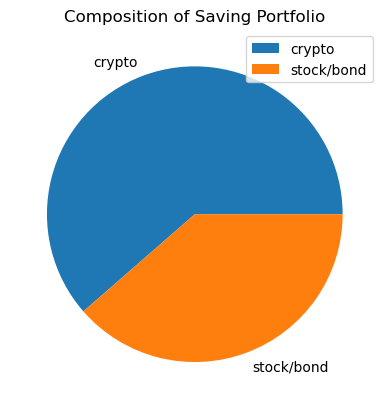

In [63]:
# Plot the total value of the member's portfolio (crypto and stock/bond) in a pie chart
savings_df.plot(kind='pie',y='amount',title='Composition of Saving Portfolio')


#### Step 4: Using Python, determine if the current portfolio has enough to create an emergency fund as part of the member’s financial plan. Ideally, an emergency fund should equal to three times the member’s monthly income. To do this, implement the following steps:

Step 1. Create a variable named `emergency_fund_value`, and set it equal to three times the value of the member’s `monthly_income` of 12000. (You set this earlier in Part 1).

Step 2. Create a series of three if statements to determine if the member’s total portfolio is large enough to fund the emergency portfolio:

* If the total portfolio value is greater than the emergency fund value, display a message congratulating the member for having enough money in this fund.

* Else if the total portfolio value is equal to the emergency fund value, display a message congratulating the member on reaching this important financial goal.

* Else the total portfolio is less than the emergency fund value, so display a message showing how many dollars away the member is from reaching the goal. (Subtract the total portfolio value from the emergency fund value.)


##### Step 4-1: Create a variable named `emergency_fund_value`, and set it equal to three times the value of the member’s `monthly_income` of 12000. (You set this earlier in Part 1).

In [64]:
# Create a variable named emergency_fund_value
emergency_fund_value = 3 * monthly_income
emergency_fund_value

36000

##### Step 4-2: Create a series of three if statements to determine if the member’s total portfolio is large enough to fund the emergency portfolio:

* If the total portfolio value is greater than the emergency fund value, display a message congratulating the member for having enough money in this fund.

* Else if the total portfolio value is equal to the emergency fund value, display a message congratulating the member on reaching this important financial goal.

* Else the total portfolio is less than the emergency fund value, so display a message showing how many dollars away the member is from reaching the goal. (Subtract the total portfolio value from the emergency fund value.)

In [69]:
#total_portfolio = 1000
if total_portfolio > emergency_fund_value:
    print('Congratulations! You have enough money')
elif total_portfolio == emergency_fund_value:
    print('Congratulations! You are reaching the financial goal')
else:
    print(f'You need {emergency_fund_value - total_portfolio} to reach the goal')

Congratulations! You have enough money


### Create the Monte Carlo Simulation

In this section, you’ll use the MCForecastTools library to create a Monte Carlo simulation for the member’s savings portfolio. To do this, complete the following steps:

1. Make an API call via the Alpaca SDK to get 3 years of historical closing prices for a traditional 60/40 portfolio split: 60% stocks (SPY) and 40% bonds (AGG).

2. Run a Monte Carlo simulation of 500 samples and 30 years for the 60/40 portfolio, and then plot the results.The following image shows the overlay line plot resulting from a simulation with these characteristics. However, because a random number generator is used to run each live Monte Carlo simulation, your image will differ slightly from this exact image:

![A screenshot depicts the resulting plot.](Images/5-4-monte-carlo-line-plot.png)

3. Plot the probability distribution of the Monte Carlo simulation. Plot the probability distribution of the Monte Carlo simulation. The following image shows the histogram plot resulting from a simulation with these characteristics. However, because a random number generator is used to run each live Monte Carlo simulation, your image will differ slightly from this exact image:

![A screenshot depicts the histogram plot.](Images/5-4-monte-carlo-histogram.png)

4. Generate the summary statistics for the Monte Carlo simulation.



#### Step 1: Make an API call via the Alpaca SDK to get 3 years of historical closing prices for a traditional 60/40 portfolio split: 60% stocks (SPY) and 40% bonds (AGG).

In [12]:
# Set start and end dates of 3 years back from your current date
# Alternatively, you can use an end date of 2020-08-07 and work 3 years back from that date 
start_date2 = pd.Timestamp('2017-08-07', tz='America/New_York').isoformat()
end_date2 = pd.Timestamp('2020-08-07', tz='America/New_York').isoformat()
display(start_date2)
end_date2

'2017-08-07T00:00:00-04:00'

'2020-08-07T00:00:00-04:00'

In [13]:
# Use the Alpaca get_bars function to make the API call to get the 3 years worth of pricing data
# The tickers and timeframe parameters should have been set in Part 1 of this activity 
# The start and end dates should be updated with the information set above
# Remember to add the df property to the end of the call so the response is returned as a DataFrame
request2 = StockBarsRequest(
    symbol_or_symbols = tickers,
    timeframe = TimeFrame.Day,
    start= start_date2,
    end= end_date2
)

prices_df3 = data_client.get_stock_bars(request2).df
prices_df3.head()

open    high       low    close  \
symbol timestamp                                                      
AGG    2017-08-07 04:00:00+00:00  109.69  109.72  109.6066  109.685   
       2017-08-08 04:00:00+00:00  109.67  109.69  109.5000  109.580   
       2017-08-09 04:00:00+00:00  109.87  109.87  109.6600  109.670   
       2017-08-10 04:00:00+00:00  109.70  109.85  109.6700  109.800   
       2017-08-11 04:00:00+00:00  109.75  109.94  109.6800  109.870   

                                     volume  trade_count        vwap  
symbol timestamp                                                      
AGG    2017-08-07 04:00:00+00:00  2796165.0       7759.0  109.674467  
       2017-08-08 04:00:00+00:00  2813251.0      12665.0  109.577497  
       2017-08-09 04:00:00+00:00  2423059.0      11035.0  109.767099  
       2017-08-10 04:00:00+00:00  2134012.0      12438.0  109.777178  
       2017-08-11 04:00:00+00:00  2109695.0      10115.0  109.861639

In [14]:
# Reorganize the DataFrame
# Separate ticker data
prices_df3 = prices_df3.reset_index()
prices_df3.head()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,AGG,2017-08-07 04:00:00+00:00,109.69,109.72,109.6066,109.685,2796165.0,7759.0,109.674467
1,AGG,2017-08-08 04:00:00+00:00,109.67,109.69,109.5000,109.580,2813251.0,12665.0,109.577497
2,AGG,2017-08-09 04:00:00+00:00,109.87,109.87,109.6600,109.670,2423059.0,11035.0,109.767099
3,AGG,2017-08-10 04:00:00+00:00,109.70,109.85,109.6700,109.800,2134012.0,12438.0,109.777178
4,AGG,2017-08-11 04:00:00+00:00,109.75,109.94,109.6800,109.870,2109695.0,10115.0,109.861639


In [15]:
# Concatenate the ticker DataFrames
AGG = prices_df3[prices_df3['symbol']=='AGG'].drop('symbol',axis=1).set_index('timestamp')
SPY = prices_df3[prices_df3['symbol']=='SPY'].drop('symbol',axis=1).set_index('timestamp')
display(AGG.head())
SPY.head()

,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,
2017-08-07 04:00:00+00:00,109.69,109.72,109.6066,109.685,2796165.0,7759.0,109.674467
2017-08-08 04:00:00+00:00,109.67,109.69,109.5000,109.580,2813251.0,12665.0,109.577497
2017-08-09 04:00:00+00:00,109.87,109.87,109.6600,109.670,2423059.0,11035.0,109.767099
2017-08-10 04:00:00+00:00,109.70,109.85,109.6700,109.800,2134012.0,12438.0,109.777178
2017-08-11 04:00:00+00:00,109.75,109.94,109.6800,109.870,2109695.0,10115.0,109.861639


,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,
2017-08-07 04:00:00+00:00,247.49,247.87,247.37,247.8400,33050019.0,100115.0,247.671941
2017-08-08 04:00:00+00:00,247.51,248.91,246.83,247.2700,64407874.0,192932.0,247.763519
2017-08-09 04:00:00+00:00,246.47,247.31,246.06,247.2700,64216201.0,223654.0,246.756887
2017-08-10 04:00:00+00:00,246.29,246.44,243.70,243.7599,123760107.0,424326.0,244.838280
2017-08-11 04:00:00+00:00,244.02,244.80,243.75,244.1100,76214881.0,278570.0,244.250040


In [16]:
prices_df4 = pd.concat([AGG,SPY],axis=1,keys=['AGG','SPY'])
prices_df4.head()

AGG                                        \
                             open    high       low    close     volume   
timestamp                                                                 
2017-08-07 04:00:00+00:00  109.69  109.72  109.6066  109.685  2796165.0   
2017-08-08 04:00:00+00:00  109.67  109.69  109.5000  109.580  2813251.0   
2017-08-09 04:00:00+00:00  109.87  109.87  109.6600  109.670  2423059.0   
2017-08-10 04:00:00+00:00  109.70  109.85  109.6700  109.800  2134012.0   
2017-08-11 04:00:00+00:00  109.75  109.94  109.6800  109.870  2109695.0   

                                                      SPY                  \
                          trade_count        vwap    open    high     low   
timestamp                                                                   
2017-08-07 04:00:00+00:00      7759.0  109.674467  247.49  247.87  247.37   
2017-08-08 04:00:00+00:00     12665.0  109.577497  247.51  248.91  246.83   
2017-08-09 04:00:00+00:00     11035.0  109.767099  246.47  247.31  246.06   
2017-08-10 04:00:00+00:00     12438.0  109.777178  246.29  246.44  243.70   
2017-08-11 04:00:00+00:00     10115.0  109.861639  244.02  244.80  243.75   

                                                                          
                              close       volume trade_count        vwap  
timestamp                                                                 
2017-08-07 04:00:00+00:00  247.8400   33050019.0    100115.0  247.671941  
2017-08-08 04:00:00+00:00  247.2700   64407874.0    192932.0  247.763519  
2017-08-09 04:00:00+00:00  247.2700   64216201.0    223654.0  246.756887  
2017-08-10 04:00:00+00:00  243.7599  123760107.0    424326.0  244.838280  
2017-08-11 04:00:00+00:00  244.1100   76214881.0    278570.0  244.250040

In [23]:
prices_df4.tail()

AGG                                        \
                             open    high       low   close      volume   
timestamp                                                                 
2020-08-03 04:00:00+00:00  119.37  119.40  119.1903  119.40  13762068.0   
2020-08-04 04:00:00+00:00  119.42  119.63  119.4200  119.63  11196655.0   
2020-08-05 04:00:00+00:00  119.39  119.49  119.3100  119.40  17692185.0   
2020-08-06 04:00:00+00:00  119.62  119.73  119.5300  119.57   4764309.0   
2020-08-07 04:00:00+00:00  119.66  119.73  119.3950  119.43   6229081.0   

                                                        SPY                  \
                          trade_count        vwap      open    high     low   
timestamp                                                                     
2020-08-03 04:00:00+00:00     36360.0  119.288647  328.3200  329.62  327.73   
2020-08-04 04:00:00+00:00     39114.0  119.543715  327.8600  330.06  327.86   
2020-08-05 04:00:00+00:00     42315.0  119.387320  331.4700  332.39  331.18   
2020-08-06 04:00:00+00:00     15939.0  119.603036  331.4799  334.46  331.13   
2020-08-07 04:00:00+00:00     15247.0  119.475223  333.2800  334.88  332.30   

                                                                       
                            close      volume trade_count        vwap  
timestamp                                                              
2020-08-03 04:00:00+00:00  328.67  54271003.0    288006.0  328.868196  
2020-08-04 04:00:00+00:00  330.00  42614516.0    250901.0  329.082842  
2020-08-05 04:00:00+00:00  332.03  43668799.0    241419.0  331.894261  
2020-08-06 04:00:00+00:00  334.32  44795942.0    290039.0  333.027721  
2020-08-07 04:00:00+00:00  334.57  57978084.0    349308.0  333.734103

#### Step 2: Run a Monte Carlo simulation of 500 samples and 30 years for the 60/40 portfolio, and then plot the results.

In [17]:
# Configure the Monte Carlo simulation to forecast 30 years cumulative returns
# The weights should be split 40% to AGG and 60% to SPY.
# Run 500 samples.
MC_even_weight = MCSimulation(
    portfolio_data = prices_df4,
    weights = [.40,.60],
    num_simulation = 500,
    num_trading_days = 252*30
)

# Printing the first five rows of the simulation input data
MC_even_weight.portfolio_data.head()


AGG                                        \
                             open    high       low    close     volume   
timestamp                                                                 
2017-08-07 04:00:00+00:00  109.69  109.72  109.6066  109.685  2796165.0   
2017-08-08 04:00:00+00:00  109.67  109.69  109.5000  109.580  2813251.0   
2017-08-09 04:00:00+00:00  109.87  109.87  109.6600  109.670  2423059.0   
2017-08-10 04:00:00+00:00  109.70  109.85  109.6700  109.800  2134012.0   
2017-08-11 04:00:00+00:00  109.75  109.94  109.6800  109.870  2109695.0   

                                                                   SPY  \
                          trade_count        vwap daily_return    open   
timestamp                                                                
2017-08-07 04:00:00+00:00      7759.0  109.674467          NaN  247.49   
2017-08-08 04:00:00+00:00     12665.0  109.577497    -0.000957  247.51   
2017-08-09 04:00:00+00:00     11035.0  109.767099     0.000821  246.47   
2017-08-10 04:00:00+00:00     12438.0  109.777178     0.001185  246.29   
2017-08-11 04:00:00+00:00     10115.0  109.861639     0.000638  244.02   

                                                                              \
                             high     low     close       volume trade_count   
timestamp                                                                      
2017-08-07 04:00:00+00:00  247.87  247.37  247.8400   33050019.0    100115.0   
2017-08-08 04:00:00+00:00  248.91  246.83  247.2700   64407874.0    192932.0   
2017-08-09 04:00:00+00:00  247.31  246.06  247.2700   64216201.0    223654.0   
2017-08-10 04:00:00+00:00  246.44  243.70  243.7599  123760107.0    424326.0   
2017-08-11 04:00:00+00:00  244.80  243.75  244.1100   76214881.0    278570.0   

                                                    
                                 vwap daily_return  
timestamp                                           
2017-08-07 04:00:00+00:00  247.671941          NaN  
2017-08-08 04:00:00+00:00  247.763519    -0.002300  
2017-08-09 04:00:00+00:00  246.756887     0.000000  
2017-08-10 04:00:00+00:00  244.838280    -0.014195  
2017-08-11 04:00:00+00:00  244.250040     0.001436

In [18]:
# Run the Monte Carlo simulation to forecast 30 years cumulative returns
MC_even_weight.calc_cumulative_return()

Running Monte Carlo simulation number 0.
Running Monte Carlo simulation number 10.
Running Monte Carlo simulation number 20.
Running Monte Carlo simulation number 30.
Running Monte Carlo simulation number 40.
Running Monte Carlo simulation number 50.
Running Monte Carlo simulation number 60.
Running Monte Carlo simulation number 70.
Running Monte Carlo simulation number 80.
Running Monte Carlo simulation number 90.
Running Monte Carlo simulation number 100.


/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resu

Running Monte Carlo simulation number 110.


/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resu

Running Monte Carlo simulation number 120.


...

Running Monte Carlo simulation number 480.


/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resu

Running Monte Carlo simulation number 490.


/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resu

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.991789,1.002759,0.999548,0.996220,1.003220,0.998900,1.008061,0.982780,1.010840,0.999023,...,0.986795,1.000422,0.995794,0.996166,0.985800,0.987570,1.014745,1.001359,0.990579,1.002518
2,1.000470,1.007980,0.992565,0.993723,1.006796,0.996975,1.009316,0.980226,1.006390,0.994753,...,0.984883,0.991653,0.992408,1.014834,0.998878,0.990710,1.030101,0.985749,0.995119,1.010117
3,1.003652,1.017816,0.979709,1.003195,1.009064,1.002176,1.014502,0.974654,1.008148,0.997479,...,0.981699,0.996701,0.997494,1.004998,1.011040,0.997064,1.033126,0.987313,1.000800,1.022340
4,1.015399,1.011626,0.984510,1.004929,0.992584,1.010019,1.019310,0.971636,1.017373,0.995195,...,0.978767,0.997390,1.001029,1.014441,1.010339,0.986098,1.055008,0.992100,0.994771,1.032585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7556,37.079801,14.533031,7.162552,2.420402,6.478714,28.138532,9.178855,3.980790,19.499063,15.941267,...,14.851457,10.351234,5.831561,2.351027,3.998184,11.216364,8.344487,2.988189,6.908166,8.899296
7557,37.300739,14.532428,7.214251,2.432195,6.434846,28.424444,9.214842,3.994236,19.667097,15.817089,...,14.756549,10.279246,5.836669,2.342393,4.023745,11.293216,8.421019,2.979594,6.880093,8.806583
7558,37.556153,14.663725,7.214614,2.389399,6.520318,28.504377,9.299333,3.990525,19.391158,15.575418,...,14.695790,10.251994,5.820379,2.342599,4.065519,11.281060,8.365959,2.992576,6.807492,8.798495
7559,37.322987,14.593728,7.227037,2.383461,6.479055,28.963670,9.305856,3.992914,19.372297,15.419195,...,14.782725,10.241593,5.843028,2.339736,4.078133,11.179233,8.422319,3.000523,6.868909,8.693551


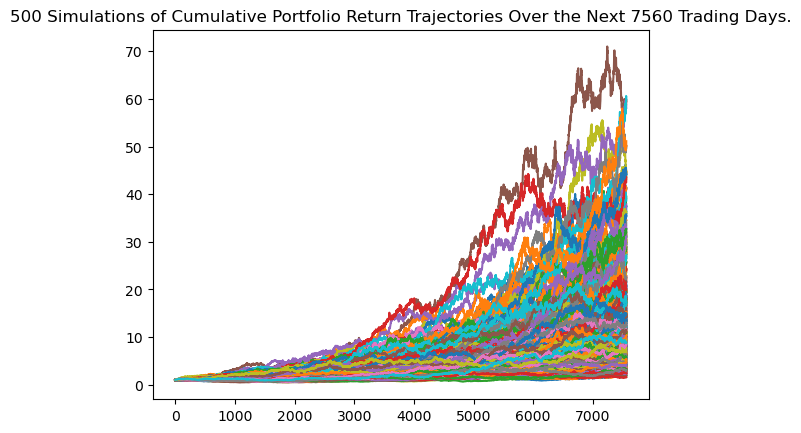

In [19]:
# Visualize the 30-year Monte Carlo simulation by creating an
# overlay line plot
even_weight_line_plot = MC_even_weight.plot_simulation()


#### Step 3: Plot the probability distribution of the Monte Carlo simulation.

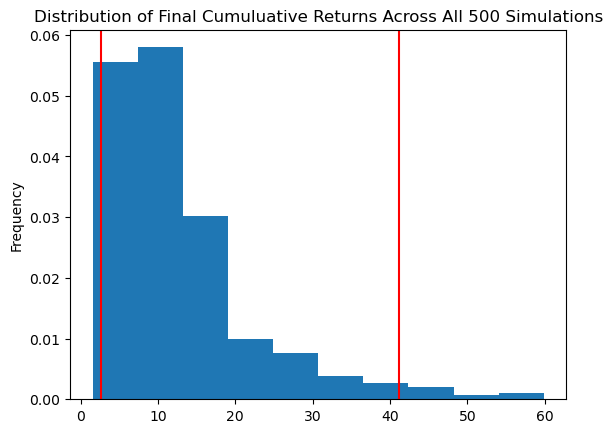

In [20]:
# Visualize the probability distribution of the 30-year Monte Carlo simulation 
# by plotting a histogram
even_weight_distribution_plot = MC_even_weight.plot_distribution()


#### Step 4: Generate the summary statistics for the Monte Carlo simulation.

In [21]:
# Generate summary statistics from the 30-year Monte Carlo simulation results
# Save the results as a variable
even_weight_table = MC_even_weight.summarize_cumulative_return()

# Review the 30-year Monte Carlo summary statistics
print(even_weight_table)

count           500.000000
mean             12.652787
std               9.632222
min               1.576490
25%               6.215608
50%               9.997346
75%              15.508821
max              59.863843
95% CI Lower      2.603722
95% CI Upper     41.131236
Name: 7560, dtype: float64


### Analyze the Retirement Portfolio Forecasts

Using the current value of only the stock and bond portion of the member's portfolio and the summary statistics that you generated from the Monte Carlo simulation, answer the following question in your Jupyter notebook:

-  What are the lower and upper bounds for the expected value of the portfolio with a 95% confidence interval?


In [24]:
# Print the current balance of the stock and bond portion of the members portfolio
total_stocks_bonds = 60688.7
total_stocks_bonds

60688.7

In [31]:
# Use the lower and upper `95%` confidence intervals to calculate the range of the possible outcomes for the current stock/bond portfolio
ci_lower_thirty_cumulative_return = float(even_weight_table.iloc[8] * total_stocks_bonds)
ci_upper_thirty_cumulative_return = float(even_weight_table.iloc[9] * total_stocks_bonds)

# Print the result of your calculations
print('The lower confidence intervals return:',ci_lower_thirty_cumulative_return)
print('The upper confidence intervals return:',ci_upper_thirty_cumulative_return)


The lower confidence intervals return: 158016.49219250612
The upper confidence intervals return: 2496201.24052936


### Forecast Cumulative Returns in 10 Years

The CTO of the credit union is impressed with your work on these planning tools but wonders if 30 years is a long time to wait until retirement. So, your next task is to adjust the retirement portfolio and run a new Monte Carlo simulation to find out if the changes will allow members to retire earlier.

For this new Monte Carlo simulation, do the following: 

- Forecast the cumulative returns for 10 years from now. Because of the shortened investment horizon (30 years to 10 years), the portfolio needs to invest more heavily in the riskier asset&mdash;that is, stock&mdash;to help accumulate wealth for retirement. 

- Adjust the weights of the retirement portfolio so that the composition for the Monte Carlo simulation consists of 20% bonds and 80% stocks. 

- Run the simulation over 500 samples, and use the same data that the API call to Alpaca generated.

- Based on the new Monte Carlo simulation, answer the following questions in your Jupyter notebook:

    - Using the current value of only the stock and bond portion of the member's portfolio and the summary statistics that you generated from the new Monte Carlo simulation, what are the lower and upper bounds for the expected value of the portfolio (with the new weights) with a 95% confidence interval?

    - Will weighting the portfolio more heavily toward stocks allow the credit union members to retire after only 10 years?


In [32]:
# Configure a Monte Carlo simulation to forecast 10 years cumulative returns
# The weights should be split 20% to AGG and 80% to SPY.
# Run 500 samples.
MC_10_year = MCSimulation(
    portfolio_data = prices_df4,
    weights = [.20,.80],
    num_simulation = 500,
    num_trading_days = 252*10
)

MC_10_year.portfolio_data.head()


AGG                                        \
                             open    high       low    close     volume   
timestamp                                                                 
2017-08-07 04:00:00+00:00  109.69  109.72  109.6066  109.685  2796165.0   
2017-08-08 04:00:00+00:00  109.67  109.69  109.5000  109.580  2813251.0   
2017-08-09 04:00:00+00:00  109.87  109.87  109.6600  109.670  2423059.0   
2017-08-10 04:00:00+00:00  109.70  109.85  109.6700  109.800  2134012.0   
2017-08-11 04:00:00+00:00  109.75  109.94  109.6800  109.870  2109695.0   

                                                                   SPY  \
                          trade_count        vwap daily_return    open   
timestamp                                                                
2017-08-07 04:00:00+00:00      7759.0  109.674467          NaN  247.49   
2017-08-08 04:00:00+00:00     12665.0  109.577497    -0.000957  247.51   
2017-08-09 04:00:00+00:00     11035.0  109.767099     0.000821  246.47   
2017-08-10 04:00:00+00:00     12438.0  109.777178     0.001185  246.29   
2017-08-11 04:00:00+00:00     10115.0  109.861639     0.000638  244.02   

                                                                              \
                             high     low     close       volume trade_count   
timestamp                                                                      
2017-08-07 04:00:00+00:00  247.87  247.37  247.8400   33050019.0    100115.0   
2017-08-08 04:00:00+00:00  248.91  246.83  247.2700   64407874.0    192932.0   
2017-08-09 04:00:00+00:00  247.31  246.06  247.2700   64216201.0    223654.0   
2017-08-10 04:00:00+00:00  246.44  243.70  243.7599  123760107.0    424326.0   
2017-08-11 04:00:00+00:00  244.80  243.75  244.1100   76214881.0    278570.0   

                                                    
                                 vwap daily_return  
timestamp                                           
2017-08-07 04:00:00+00:00  247.671941          NaN  
2017-08-08 04:00:00+00:00  247.763519    -0.002300  
2017-08-09 04:00:00+00:00  246.756887     0.000000  
2017-08-10 04:00:00+00:00  244.838280    -0.014195  
2017-08-11 04:00:00+00:00  244.250040     0.001436

In [33]:
# Run the Monte Carlo simulation to forecast 10 years cumulative returns
MC_10_year.calc_cumulative_return()

Running Monte Carlo simulation number 0.
Running Monte Carlo simulation number 10.
Running Monte Carlo simulation number 20.
Running Monte Carlo simulation number 30.
Running Monte Carlo simulation number 40.
Running Monte Carlo simulation number 50.
Running Monte Carlo simulation number 60.
Running Monte Carlo simulation number 70.
Running Monte Carlo simulation number 80.
Running Monte Carlo simulation number 90.
Running Monte Carlo simulation number 100.
Running Monte Carlo simulation number 110.


/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resu

Running Monte Carlo simulation number 120.
Running Monte Carlo simulation number 130.


/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resu

Running Monte Carlo simulation number 140.
Running Monte Carlo simulation number 150.


...

Running Monte Carlo simulation number 470.
Running Monte Carlo simulation number 480.


/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resu

Running Monte Carlo simulation number 490.


/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  portfolio_cumulative_returns[n] = (1 + sim_df.fillna(0)).cumprod()
/Users/kellen/Documents/Linlin_UCBerkeley/Module_5/MCForecastTools26.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resu

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.996835,0.988995,0.991205,1.001279,0.985794,0.996355,1.004245,1.003436,0.992753,0.999848,...,1.018999,1.012967,0.997519,1.016458,0.982786,0.971352,0.999278,1.030472,0.990490,0.996582
2,1.002727,0.999070,0.984713,0.985653,0.978518,1.010012,1.006898,0.996320,1.003432,1.004090,...,1.005059,1.028221,0.990506,1.018252,0.965392,0.986238,0.991302,1.031315,0.998612,1.011006
3,0.994128,1.004122,0.996917,0.991095,0.978708,0.990259,1.010541,0.991966,1.001019,1.008228,...,0.992873,1.029277,0.992710,1.030106,0.968777,0.995999,0.993279,1.042236,0.992562,1.012056
4,0.973557,1.011119,1.008745,0.994095,0.972390,0.989568,1.010050,0.979771,0.987577,1.009948,...,1.002529,1.048868,0.986742,1.031168,0.973446,0.984792,0.989265,1.041474,0.986418,1.018175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2516,4.681604,3.085568,1.577970,3.442656,2.879389,1.185377,1.489151,1.984502,2.631719,1.441649,...,2.192607,1.927179,1.308910,3.390526,4.350602,4.351235,3.166214,2.063233,3.392313,4.007544
2517,4.644160,3.082432,1.571545,3.492948,2.876665,1.183410,1.496824,1.999389,2.615266,1.435823,...,2.163837,1.911060,1.306185,3.396179,4.252236,4.331075,3.133759,2.044286,3.365910,4.092289
2518,4.629488,3.117760,1.558833,3.512530,2.859387,1.198238,1.475515,1.999212,2.599979,1.440283,...,2.203871,1.940343,1.316284,3.402811,4.232420,4.263972,3.117795,2.046635,3.380643,4.088617
2519,4.610003,3.164319,1.569385,3.569255,2.867430,1.197818,1.505996,1.977441,2.614432,1.457343,...,2.192251,1.916500,1.303991,3.418884,4.257000,4.347659,3.062064,2.085597,3.418771,4.075557


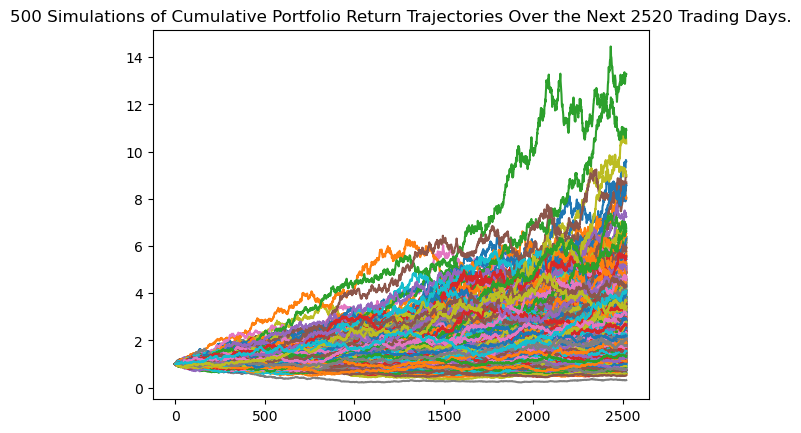

In [34]:
# Visualize the 10-year Monte Carlo simulation by creating an
# overlay line plot
mc_10_line_plot = MC_10_year.plot_simulation()


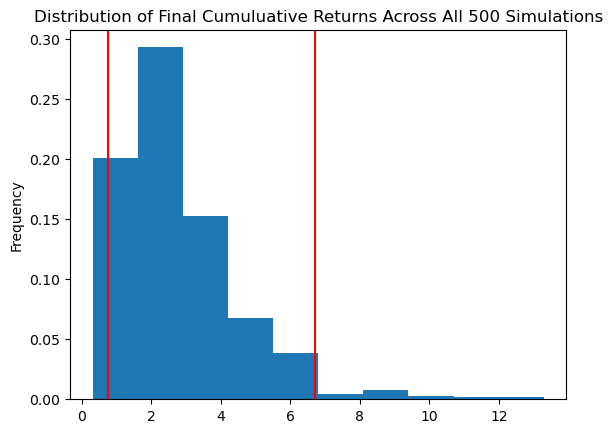

In [35]:
# Visualize the probability distribution of the 10-year Monte Carlo simulation 
# by plotting a histogram
mc_10_distribution_plot = MC_10_year.plot_distribution()


In [36]:
# Generate summary statistics from the 10-year Monte Carlo simulation results
# Save the results as a variable
mc_10_table = MC_10_year.summarize_cumulative_return()

# Review the 10-year Monte Carlo summary statistics
print(mc_10_table)

count           500.000000
mean              2.805760
std               1.724641
min               0.313776
25%               1.575377
50%               2.388410
75%               3.567743
max              13.290988
95% CI Lower      0.744199
95% CI Upper      6.695950
Name: 2520, dtype: float64


### Answer the following questions:

#### Question: Using the current value of only the stock and bond portion of the member's portfolio and the summary statistics that you generated from the new Monte Carlo simulation, what are the lower and upper bounds for the expected value of the portfolio (with the new weights) with a 95% confidence interval?

In [37]:
# Print the current balance of the stock and bond portion of the members portfolio
total_stocks_bonds = 60688.7
total_stocks_bonds


60688.7

In [40]:
# Use the lower and upper `95%` confidence intervals to calculate the range of the possible outcomes for the current stock/bond portfolio
ci_lower_ten_cumulative_return = float(mc_10_table.iloc[8] * total_stocks_bonds)
ci_upper_ten_cumulative_return = float(mc_10_table.iloc[9] * total_stocks_bonds)

# Print the result of your calculations
print('The lower confidence intervals 10_year return:',ci_lower_ten_cumulative_return)
print('The upper confidence intervals 10_year return:',ci_upper_ten_cumulative_return)

The lower confidence intervals 10_year return: 45164.49201651084
The upper confidence intervals 10_year return: 406368.4783154551


#### Question: Will weighting the portfolio more heavily to stocks allow the credit union members to retire after only 10 years?

The Monta Carlo simulation suggests that after 10 years, the lower bound of the confidence interval is approximately 45000, while the upper bound reaches about 400000. The lower bound falls below the initial investment and is significantly insufficient for retirement needs. This risk is primarily driven by stock market volatility.